In [1]:
import pandas
import torch
import torchvision
import glob

/Users/tudor/Documents/Work_AI/.venv_3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
img_paths = glob.glob("WaterMeters/images/*.jpg")
mask_paths = glob.glob("WaterMeters/masks/*.jpg")

In [3]:
id_to_img = {}
id_to_val = {}

for i, path in enumerate(img_paths):
    id = int(path.split('/')[2].split("_")[1])
    v1 = int(path.split('/')[2].split("_")[3])
    v2 = int(path.split('/')[2].split("_")[4][:-4])

    id_to_img[id] = path.split('/')[2];
    id_to_val[id] = (v1, v2);

In [4]:
import PIL.Image as Image
from PIL import ImageOps
import numpy as np
import tqdm

train_X = []
train_y = []

for i in tqdm.tqdm(range(4, len(img_paths) + 1, 1)):
    img = Image.open("WaterMeters/images/" + id_to_img[i])
    mask = Image.open("WaterMeters/masks/" + id_to_img[i])

    img = ImageOps.exif_transpose(img)
    mask = ImageOps.exif_transpose(mask)

    img = img.resize((128, 128))
    mask = mask.resize((128, 128))

    train_X.append(np.array(img))
    train_y.append(np.array(mask))

    

100%|██████████| 1241/1241 [01:01<00:00, 20.27it/s]


In [5]:
from torchvision.transforms import v2
import random

flip_h = v2.RandomHorizontalFlip(p=1.0)
flip_v = v2.RandomVerticalFlip(p=1.0)

for i in tqdm.tqdm(range(len(train_X))):
    img = train_X[i]
    label = train_y[i]

    for j in range(4):
        img_aug = img
        label_aug = label;

        if random.random() < 0.5:
            img_aug = flip_h(img_aug)
            label_aug = flip_h(label_aug)
        if random.random() < 0.5:
            img_aug = flip_v(img_aug)
            label_aug = flip_v(label_aug)

        
        train_X.append(img_aug)
        train_y.append(label_aug)

100%|██████████| 1241/1241 [00:00<00:00, 3957.63it/s]


In [6]:
len(train_X)

6205

In [7]:
train_X = np.array(train_X) / 255
train_y = np.array(train_y) / 255

In [8]:
# perm = np.random.permutation(len(train_X))

# train_X = train_X[perm]

# np.random.shuffle(train_X)
# np.random.shuffle(train_y)


In [9]:
# train_X

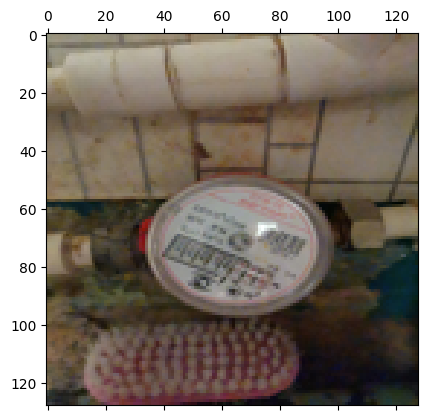

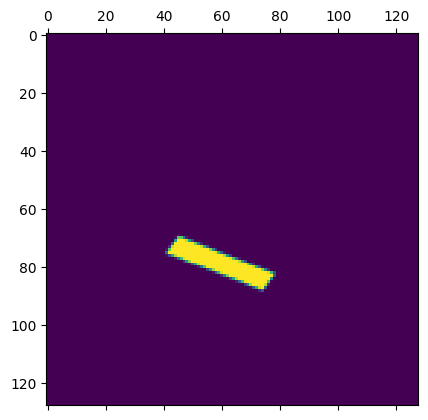

In [10]:
import matplotlib.pyplot as plt

plt.matshow(train_X[5])
plt.matshow(train_y[5])


In [11]:
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision import models
 
model = models.segmentation.deeplabv3_resnet101(
    pretrained=True, progress=True)
model.classifier = DeepLabHead(2048, 1)
model.train()


/Users/tudor/Documents/Work_AI/.venv_3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tudor/Documents/Work_AI/.venv_3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [21]:
import torch.nn as nn

batch_size = 10
device = torch.device("cpu")
model = model.to(device)
opt = torch.optim.Adam(model.parameters())
loss_fn = nn.MSELoss()


In [26]:
def train(epoch):
    print("Epoch:", epoch)

    train_loss = 0
    model.train()

    for i in tqdm.tqdm(range(0, len(train_X[:100]), batch_size)):
        X = torch.Tensor(train_X[i:i + batch_size]).permute(0, 3, 1, 2).to(device)
        y = torch.Tensor(train_y[i:i + batch_size]).reshape((-1, 128, 128, 1)).permute(0, 3, 1, 2).to(device)

        opt.zero_grad()

        output = model(X)

        output = output["out"]

        loss = loss_fn(output, y)

        loss.backward()
        opt.step()

        train_loss += loss.item()

    model.eval()
    idx = np.random.randint(0, len(train_X) - 1)
    test_1 = torch.Tensor(train_X[idx]).permute(2, 0, 1).to(device).reshape((1, 3, 128, 128))
    print(test_1.shape)
    pred_1 = model(test_1)["out"].detach().cpu().permute(0, 2, 3, 1).numpy()[0]
    print(pred_1.shape)

    plt.matshow(train_X[idx])
    plt.matshow(pred_1)
    plt.show()

    print("Loss:", train_loss / (len(train_X)))



Epoch: 0


100%|██████████| 10/10 [01:08<00:00,  6.84s/it]


torch.Size([1, 3, 128, 128])
(128, 128, 1)


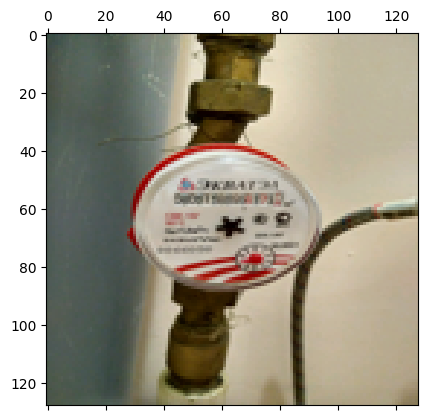

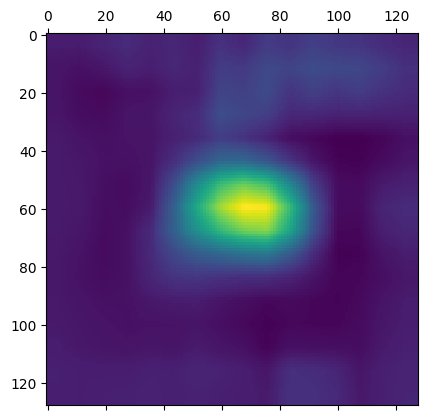

Loss: 2.914346652488186e-05


: 

In [ ]:
train(0)

In [ ]:
train_X

array([[[[0.06666667, 0.03137255, 0.00392157],
         [0.08627451, 0.03137255, 0.00392157],
         [0.09411765, 0.02745098, 0.00784314],
         ...,
         [0.29019608, 0.21960784, 0.1254902 ],
         [0.29803922, 0.22352941, 0.1254902 ],
         [0.30196078, 0.21960784, 0.12156863]],

        [[0.06666667, 0.02745098, 0.00392157],
         [0.08627451, 0.03137255, 0.00784314],
         [0.09411765, 0.03137255, 0.00784314],
         ...,
         [0.29019608, 0.21960784, 0.1254902 ],
         [0.29411765, 0.21960784, 0.12156863],
         [0.29411765, 0.21568627, 0.10196078]],

        [[0.06666667, 0.03137255, 0.01176471],
         [0.08627451, 0.03529412, 0.00392157],
         [0.09019608, 0.03529412, 0.        ],
         ...,
         [0.29019608, 0.21960784, 0.12941176],
         [0.29019608, 0.21960784, 0.1254902 ],
         [0.29019608, 0.21176471, 0.10588235]],

        ...,

        [[0.33333333, 0.27843137, 0.17254902],
         [0.32156863, 0.25882353, 0.15686275]

In [ ]:
model.eval()  # Important!
with torch.no_grad():
    image = torch.Tensor([train_X[0]]).permute(0, 3, 1, 2)  # [1, C, H, W]
    pred = model(image)['out']  # Output is typically under 'out' for torchvision models


In [ ]:
pred = pred.permute(0, 2, 3, 1)

In [ ]:
pred = pred

In [ ]:
pred

tensor([[[[ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          ...,
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827]],

         [[ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          ...,
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827]],

         [[ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          [ 0.1771, -0.0418],
          ...,
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827],
          [ 0.1697, -0.0827]],

         ...,

         [[ 0.2236, -0.1022],
          [ 0.2236, -0.1022],
          [ 0.2236, -0.1022],
          ...,
          [ 0.1873, -0.1262],
          [ 0.1873, -0.1262],
          [ 0.1873, -0.1262]],

         [[ 0.2236, -0.1022],
          [ 0.2236, -0.1022],
          [ 0.2236, -0.1022],
          ...,
          [ 0.1873, -0.1262],
          [ 0.1873, -0.1262],
          [ 0.1873, -0.1262]],



In [ ]:
pred[:, :, :, 1]

tensor([[[-0.0418, -0.0418, -0.0418,  ..., -0.0827, -0.0827, -0.0827],
         [-0.0418, -0.0418, -0.0418,  ..., -0.0827, -0.0827, -0.0827],
         [-0.0418, -0.0418, -0.0418,  ..., -0.0827, -0.0827, -0.0827],
         ...,
         [-0.1022, -0.1022, -0.1022,  ..., -0.1262, -0.1262, -0.1262],
         [-0.1022, -0.1022, -0.1022,  ..., -0.1262, -0.1262, -0.1262],
         [-0.1022, -0.1022, -0.1022,  ..., -0.1262, -0.1262, -0.1262]]])

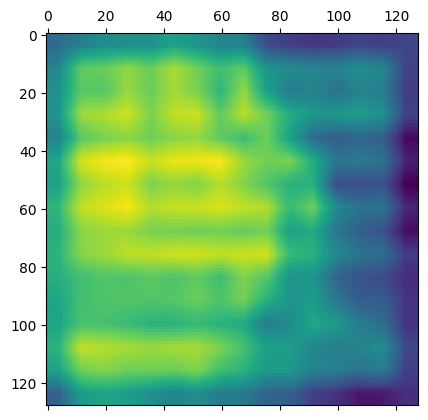

In [ ]:

plt.matshow((pred[:, :, :, 0][0] + pred[:, :, :, 1][0]) / 2)

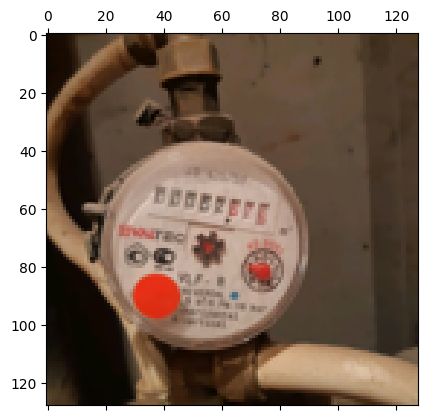

In [ ]:
plt.matshow(train_X[0])